In [1]:
import yfinance as yf
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [2]:

# sp500_ticker = yf.Ticker('^GSPC')
# sp500 = sp500_ticker.history(start="1990-01-01", end="2025-02-07")


# apple_ticker = yf.Ticker('AAPL')
# apple = apple_ticker.history(start="2020-01-01", end="2025-03-05")

tickers = ["PL=F", "WPM", "AAPL", "SONY", "SWEGX", "SUPN", "LEG", "CTSH", "BAC", "WPM", "SSRM", "NVDA", "BMO","^GSPC"]

data = yf.download(tickers,start="2020-01-01",end="2025-03-05")["Close"]
data = data.reset_index()
data = data.dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  13 of 13 completed


##### Calculate daily percentage change

In [3]:
# data['Price Ratio'] = data['PL=F'].divide(data.WPM)
data_returns = pd.DataFrame()
data_returns['Date'] = data.Date
for col in data.columns[1:]:
    data_returns[col + ' Returns'] = data[col].pct_change(fill_method=None)

data_returns = data_returns.dropna()

##### Correlation between each stocks returns and "PL=F"

In [4]:
data_returns.iloc[:,1:].corr().loc[:,'PL=F Returns']

AAPL Returns     0.193906
BAC Returns      0.233188
BMO Returns      0.322443
CTSH Returns     0.238089
LEG Returns      0.231863
NVDA Returns     0.185803
PL=F Returns     1.000000
SONY Returns     0.218286
SSRM Returns     0.374638
SUPN Returns     0.086950
SWEGX Returns    0.359956
WPM Returns      0.434887
^GSPC Returns    0.302444
Name: PL=F Returns, dtype: float64

* lowest correlation is SUPN - Supernus Pharmaceuticals Inc
*  highest correlation is WPM -  Wheaton Precious Metals Corp

In [5]:
# platinum ticker
platinum_ticker = yf.Ticker("PL=F")
platinum = platinum_ticker.history(start="2020-01-01")
platinum.reset_index(inplace=True)
platinum['Date'] = pd.to_datetime(platinum['Date']).dt.date

#### SOURCE ####
# https://fred.stlouisfed.org/series/EFFR
effr = pd.read_csv('EFFR.csv')
effr['observation_date'] = pd.to_datetime(effr['observation_date']).dt.date

# Consumer Price Index
cpi = web.DataReader("CPIAUCNS", "fred", start="2020-01-01", end=effr.observation_date.max())
cpi.reset_index(inplace=True)
cpi['DATE'] = pd.to_datetime(cpi['DATE']).dt.date

# U.S. Dollar Index (DXY)
dxy = yf.download("DX-Y.NYB", start="2020-01-01", interval="1d", end=effr.observation_date.max())
dxy.reset_index(inplace=True)
dxy['Date'] = pd.to_datetime(dxy['Date']).dt.date
dxy.columns = [x[0] for x in dxy.columns]

[*********************100%***********************]  1 of 1 completed


In [6]:
### FILTER DATES ###
platinum_data = platinum[platinum.Date >= effr.observation_date.min()]

# calculate daily returns
platinum_data['Returns'] = platinum_data['Close'].pct_change()
#### CALCULATE 30 DAY VOLATILITY #### 
platinum_data['Volatility'] = platinum_data['Returns'].rolling(window=30,min_periods=1).std()
platinum_data['Annual Volatility'] = platinum_data['Volatility'] * np.sqrt(252) 


### MERGE PLATINUM AND INTEREST RATE DATASET ###
df = platinum_data.merge(effr, how='inner', left_on='Date', right_on='observation_date').drop('observation_date',axis=1)


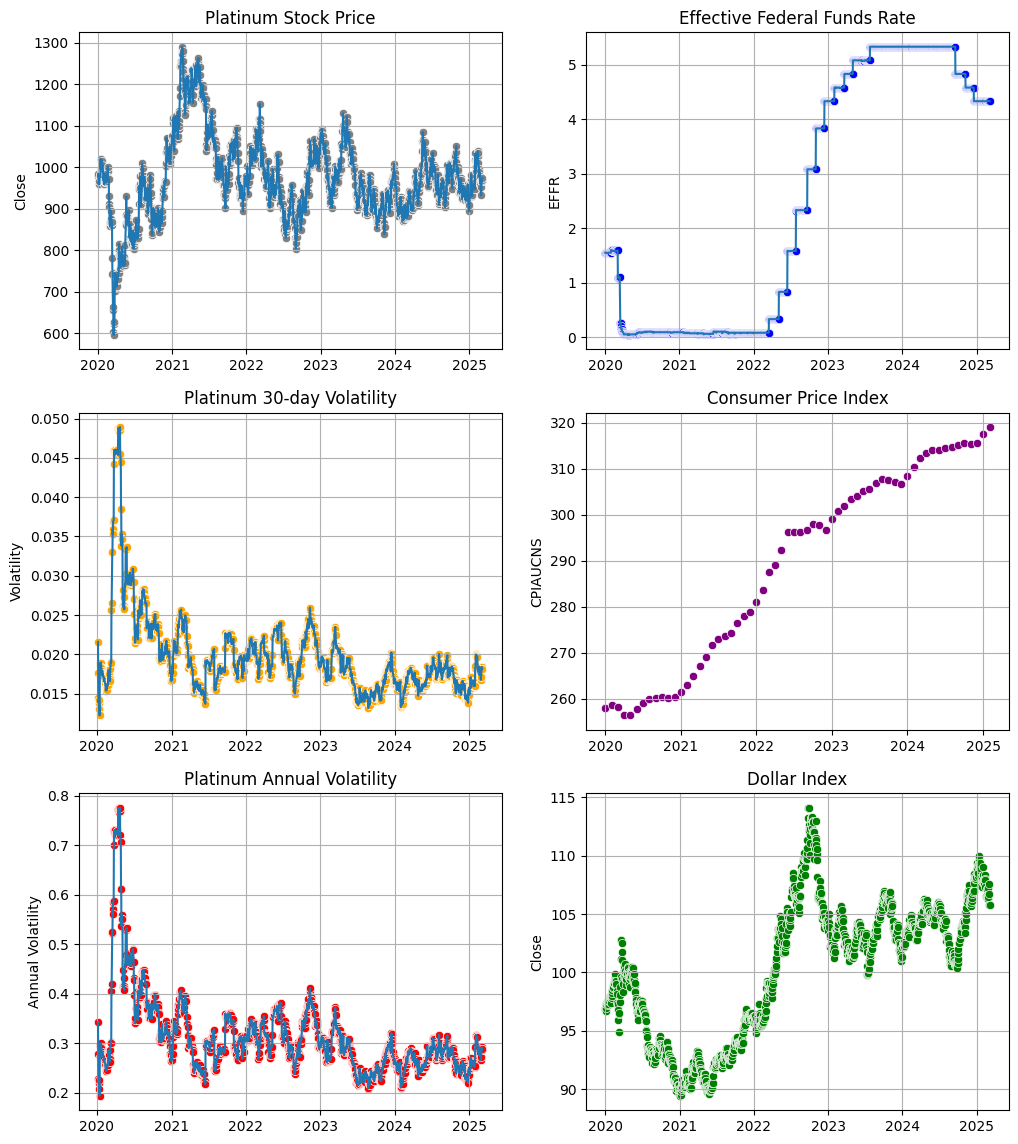

In [7]:
fig,axs = plt.subplots(3,2,figsize=(12,14))


sns.scatterplot(data=df,x='Date',y='Close',ax=axs[0,0],color='grey')
sns.lineplot(data=df,x='Date',y='Close',ax=axs[0,0])
axs[0,0].set_title(label='Platinum Stock Price')


sns.scatterplot(data=df,x='Date',y='Volatility',ax=axs[1,0],color='orange')
sns.lineplot(data=df,x='Date',y='Volatility',ax=axs[1,0])
axs[1,0].set_title(label='Platinum 30-day Volatility')

sns.scatterplot(data=df,x='Date',y='Annual Volatility',ax=axs[2,0],color='red')
sns.lineplot(data=df,x='Date',y='Annual Volatility',ax=axs[2,0])
axs[2,0].set_title(label='Platinum Annual Volatility')


sns.scatterplot(data=df,x='Date',y='EFFR',ax=axs[0,1],color='blue')
sns.lineplot(data=df,x='Date',y='EFFR',ax=axs[0,1])
axs[0,1].set_title(label='Effective Federal Funds Rate')

sns.scatterplot(data=cpi,x='DATE',y='CPIAUCNS',ax=axs[1,1],color='purple')
# sns.lineplot(data=cpi,x='DATE',y='CPIAUCNS',ax=axs[1,1])
axs[1,1].set_title(label='Consumer Price Index')

sns.scatterplot(data=dxy,x='Date',y='Close',ax=axs[2,1],color='green')
# sns.lineplot(data=dxy,x='Date',y='Close',ax=axs[2,1])
axs[2,1].set_title(label='Dollar Index')

for row in range(3):
    for col in range(2):
        axs[row,col].grid(visible=True,axis='both')
        axs[row,col].set_xlabel('')




In [8]:
cpi.head()


,DATE,CPIAUCNS
0,2020-01-01,257.971
1,2020-02-01,258.678
2,2020-03-01,258.115
3,2020-04-01,256.389
4,2020-05-01,256.394


In [44]:
df.head(10)
master_df = plat_df.merge(effr, how='inner', left_on='Date', right_on='observation_date').drop('observation_date',axis=1)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,Volatility,Annual Volatility,EFFR
0,2020-01-02,985.000000,990.000000,978.599976,978.599976,2,0.0,0.0,NaN,NaN,NaN,1.55
1,2020-01-03,986.500000,987.200012,980.599976,984.500000,32,0.0,0.0,0.006029,NaN,NaN,1.55
2,2020-01-06,985.799988,985.799988,960.000000,960.400024,65,0.0,0.0,-0.024479,0.021573,0.342457,1.55
3,2020-01-07,965.299988,973.000000,959.900024,966.000000,55,0.0,0.0,0.005831,0.017557,0.278711,1.55
4,2020-01-08,968.900024,968.900024,956.000000,959.000000,23,0.0,0.0,-0.007246,0.014416,0.228842,1.55
5,2020-01-09,967.099976,967.099976,967.099976,967.099976,0,0.0,0.0,0.008446,0.013851,0.219872,1.55
6,2020-01-10,972.000000,981.500000,972.000000,981.200012,12,0.0,0.0,0.014580,0.014173,0.224986,1.54
7,2020-01-13,978.799988,978.799988,970.099976,977.299988,6,0.0,0.0,-0.003975,0.013049,0.207152,1.54
8,2020-01-14,982.200012,982.200012,981.500000,982.200012,9,0.0,0.0,0.005014,0.012217,0.193935,1.54
9,2020-01-15,993.400024,1020.400024,993.400024,1020.400024,1,0.0,0.0,0.038892,0.017151,0.272263,1.54


In [9]:
dxy.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,96.849998,96.870003,96.430000,96.480003,0
1,2020-01-03,96.839996,97.110001,96.709999,96.790001,0
2,2020-01-06,96.669998,96.900002,96.540001,96.900002,0
3,2020-01-07,96.980003,97.089996,96.620003,96.650002,0
4,2020-01-08,97.300003,97.330002,96.820000,96.830002,0


In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
minmax = MinMaxScaler()
silver_scaled = minmax.fit_transform(df.iloc[:,1:])

In [23]:
platinum_data.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,Volatility,Annual Volatility,Log_Returns,Log_Volatility
0,2020-01-02,985.000000,990.000000,978.599976,978.599976,2,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,986.500000,987.200012,980.599976,984.500000,32,0.0,0.0,0.006029,NaN,NaN,-5.111166,NaN
2,2020-01-06,985.799988,985.799988,960.000000,960.400024,65,0.0,0.0,-0.024479,0.021573,0.342457,NaN,-3.836325
3,2020-01-07,965.299988,973.000000,959.900024,966.000000,55,0.0,0.0,0.005831,0.017557,0.278711,-5.144588,-4.042295
4,2020-01-08,968.900024,968.900024,956.000000,959.000000,23,0.0,0.0,-0.007246,0.014416,0.228842,NaN,-4.239438
5,2020-01-09,967.099976,967.099976,967.099976,967.099976,0,0.0,0.0,0.008446,0.013851,0.219872,-4.774030,-4.279426
6,2020-01-10,972.000000,981.500000,972.000000,981.200012,12,0.0,0.0,0.014580,0.014173,0.224986,-4.228124,-4.256430
7,2020-01-13,978.799988,978.799988,970.099976,977.299988,6,0.0,0.0,-0.003975,0.013049,0.207152,NaN,-4.339018
8,2020-01-14,982.200012,982.200012,981.500000,982.200012,9,0.0,0.0,0.005014,0.012217,0.193935,-5.295553,-4.404949
9,2020-01-15,993.400024,1020.400024,993.400024,1020.400024,1,0.0,0.0,0.038892,0.017151,0.272263,-3.246959,-4.065703


In [24]:
platinum_data['Log_Returns'] = np.log(platinum_data['Returns'])
platinum_data['Log_Volatility'] = np.log(platinum_data['Volatility'])

platinum_data.head()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,Volatility,Annual Volatility,Log_Returns,Log_Volatility
0,2020-01-02,985.000000,990.000000,978.599976,978.599976,2,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,986.500000,987.200012,980.599976,984.500000,32,0.0,0.0,0.006029,NaN,NaN,-5.111166,NaN
2,2020-01-06,985.799988,985.799988,960.000000,960.400024,65,0.0,0.0,-0.024479,0.021573,0.342457,NaN,-3.836325
3,2020-01-07,965.299988,973.000000,959.900024,966.000000,55,0.0,0.0,0.005831,0.017557,0.278711,-5.144588,-4.042295
4,2020-01-08,968.900024,968.900024,956.000000,959.000000,23,0.0,0.0,-0.007246,0.014416,0.228842,NaN,-4.239438


In [29]:
plat_df = platinum_data[['Date', 'Close','Log_Volatility', 'Volatility', 'Returns', 'Volume']]
plat_df.head(40)

,Date,Close,Log_Volatility,Volatility,Returns,Volume
0,2020-01-02,978.599976,NaN,NaN,NaN,2
1,2020-01-03,984.500000,NaN,NaN,0.006029,32
2,2020-01-06,960.400024,-3.836325,0.021573,-0.024479,65
3,2020-01-07,966.000000,-4.042295,0.017557,0.005831,55
4,2020-01-08,959.000000,-4.239438,0.014416,-0.007246,23
5,2020-01-09,967.099976,-4.279426,0.013851,0.008446,0
6,2020-01-10,981.200012,-4.256430,0.014173,0.014580,12
7,2020-01-13,977.299988,-4.339018,0.013049,-0.003975,6
8,2020-01-14,982.200012,-4.404949,0.012217,0.005014,9
9,2020-01-15,1020.400024,-4.065703,0.017151,0.038892,1


/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/3998138853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Date'] = pd.to_datetime(plat_df['Date'])


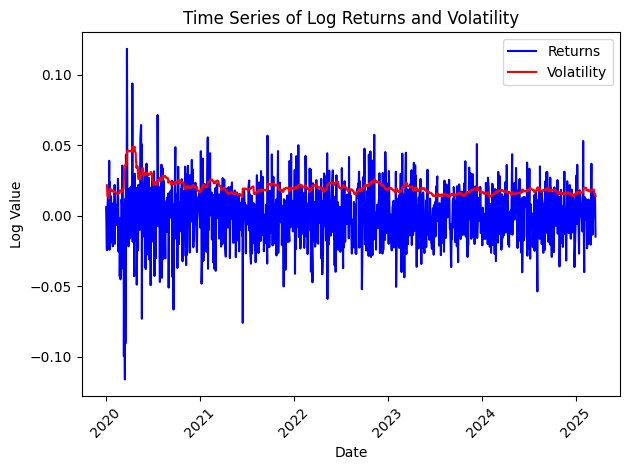

In [27]:
plat_df['Date'] = pd.to_datetime(plat_df['Date'])


sns.lineplot(x='Date', y='Returns', data=plat_df, label='Returns', color='blue')
sns.lineplot(x='Date', y='Volatility', data=plat_df, label='Volatility', color='red')


plt.xlabel('Date')
plt.ylabel('Log Value')
plt.title('Time Series of Log Returns and Volatility')
plt.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/2215132772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Date'] = pd.to_datetime(plat_df['Date'])


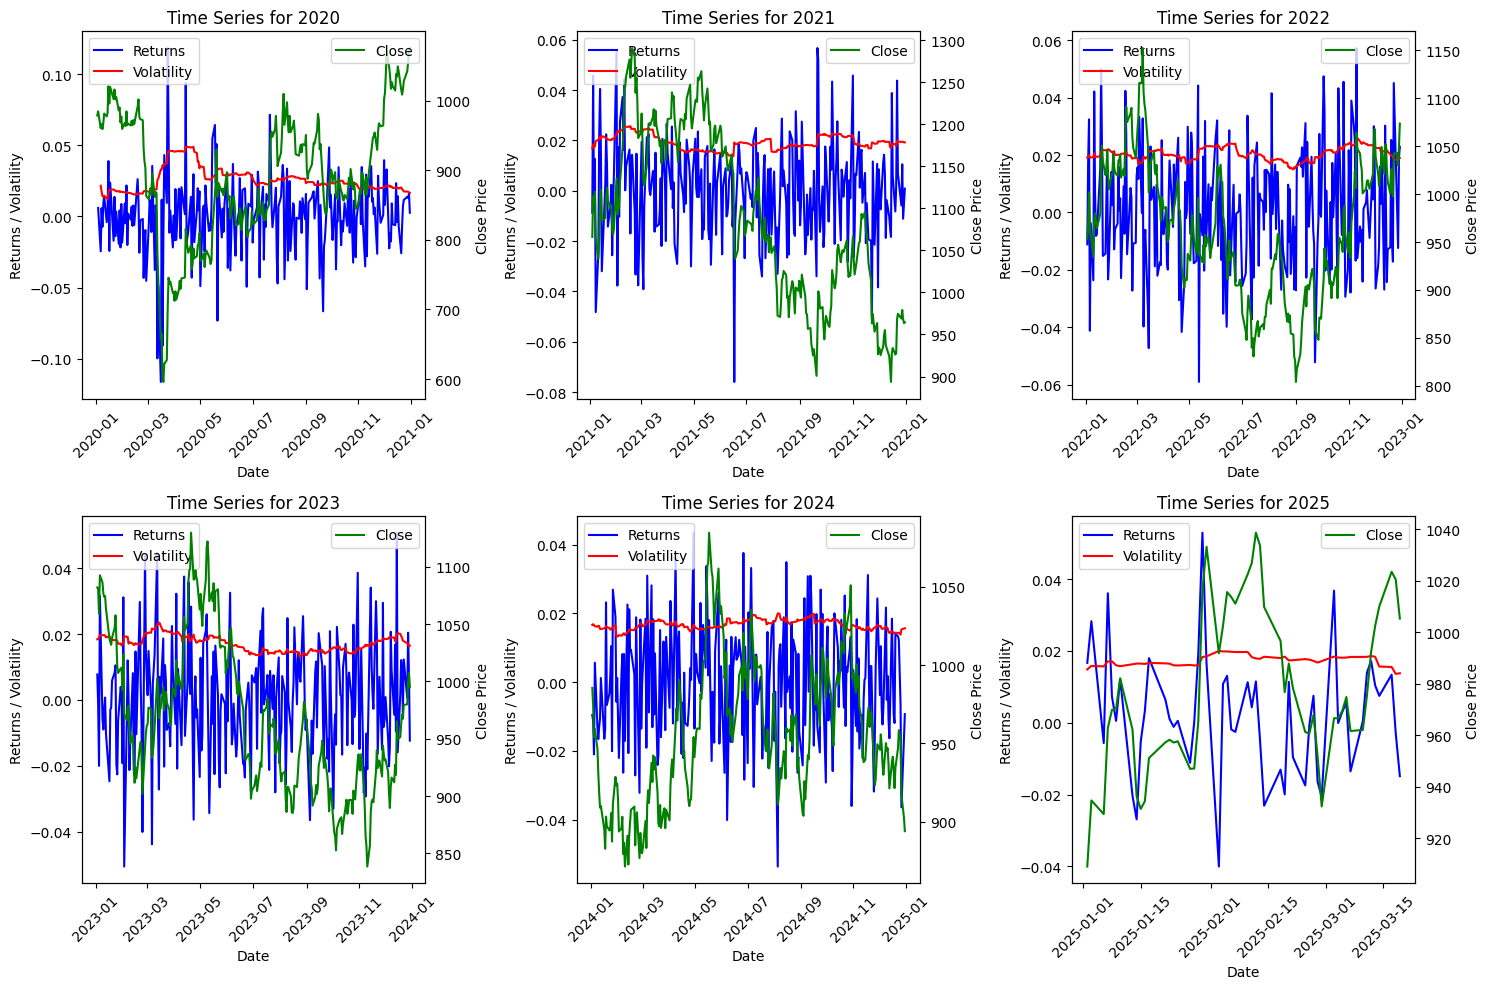

In [32]:

plat_df['Date'] = pd.to_datetime(plat_df['Date'])


years = [2020, 2021, 2022, 2023, 2024, 2025]


plt.figure(figsize=(15, 10))


for i, year in enumerate(years):
   
    year_data = plat_df[plat_df['Date'].dt.year == year]
    
    
    ax1 = plt.subplot(2, 3, i+1) 
    sns.lineplot(x='Date', y='Returns', data=year_data, label='Returns', color='blue', ax=ax1)
    sns.lineplot(x='Date', y='Volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    
   
    ax2 = ax1.twinx()
    sns.lineplot(x='Date', y='Close', data=year_data, label='Close', color='green', ax=ax2)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {year}')
    
   
    ax2.set_ylabel('Close Price')
    
    
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    
    ax1.tick_params(axis='x', rotation=45)


plt.tight_layout()


plt.show()


/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/4245983832.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Date'] = pd.to_datetime(plat_df['Date'])


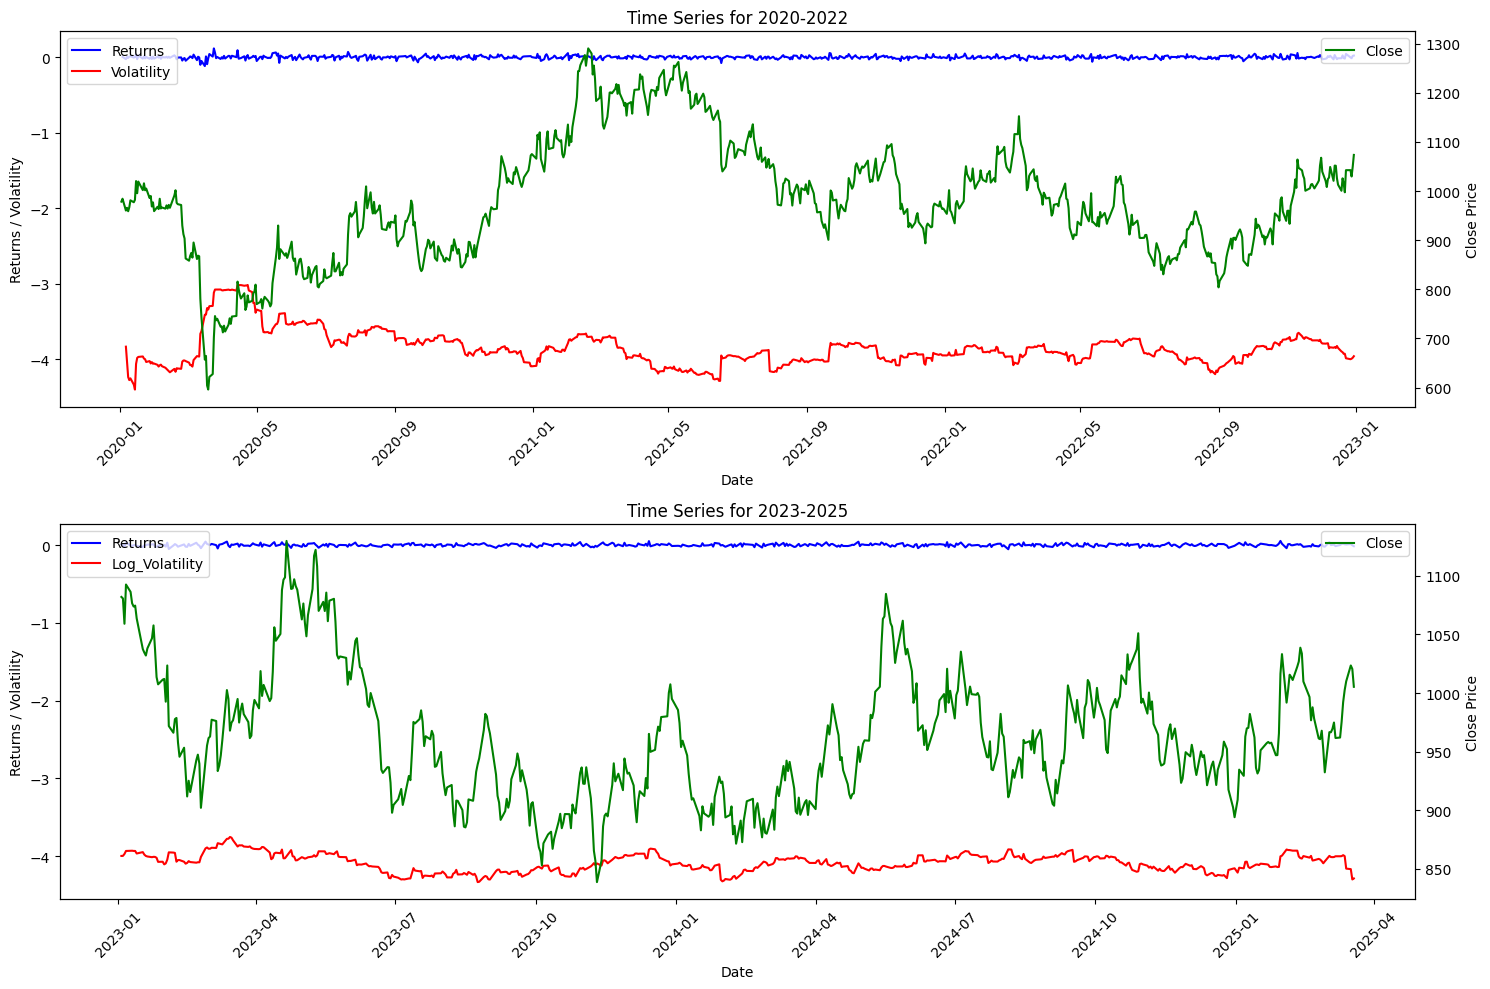

In [34]:

plat_df['Date'] = pd.to_datetime(plat_df['Date'])

# Create a figure with subplots (2 rows, 1 column)
plt.figure(figsize=(15, 10))

# List of years for each plot
years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

# Plot 1 for 2020-2022
ax1 = plt.subplot(2, 1, 1)  # 2 rows, 1 column, first subplot

# Filter data for the years 2020-2022
data_2020_2022 = plat_df[plat_df['Date'].dt.year.isin(years_1)]

# Plot Returns and Volatility for the 2020-2022 period on primary y-axis
sns.lineplot(x='Date', y='Returns', data=data_2020_2022, label='Returns', color='blue', ax=ax1)
sns.lineplot(x='Date', y='Log_Volatility', data=data_2020_2022, label='Volatility', color='red', ax=ax1)

# Create a secondary y-axis for the Close price
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='Close', data=data_2020_2022, label='Close', color='green', ax=ax2)

# Set titles and labels for the first subplot
ax1.set_xlabel('Date')
ax1.set_ylabel('Returns / Volatility')
ax1.set_title('Time Series for 2020-2022')

# Set secondary axis labels for Close price
ax2.set_ylabel('Close Price')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Rotate x-ticks for better readability
ax1.tick_params(axis='x', rotation=45)

# Plot 2 for 2023-2025
ax3 = plt.subplot(2, 1, 2)  # 2 rows, 1 column, second subplot

# Filter data for the years 2023-2025
data_2023_2025 = plat_df[plat_df['Date'].dt.year.isin(years_2)]

# Plot Returns and Volatility for the 2023-2025 period on primary y-axis
sns.lineplot(x='Date', y='Returns', data=data_2023_2025, label='Returns', color='blue', ax=ax3)
sns.lineplot(x='Date', y='Log_Volatility', data=data_2023_2025, label='Log_Volatility', color='red', ax=ax3)

# Create a secondary y-axis for the Close price
ax4 = ax3.twinx()
sns.lineplot(x='Date', y='Close', data=data_2023_2025, label='Close', color='green', ax=ax4)

# Set titles and labels for the second subplot
ax3.set_xlabel('Date')
ax3.set_ylabel('Returns / Volatility')
ax3.set_title('Time Series for 2023-2025')

# Set secondary axis labels for Close price
ax4.set_ylabel('Close Price')

# Add legends
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')

# Rotate x-ticks for better readability
ax3.tick_params(axis='x', rotation=45)

# Adjust layout for the subplots
plt.tight_layout()

# Show the plot
plt.show()


/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/2680176934.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Date'] = pd.to_datetime(plat_df['Date'])
/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/2680176934.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Normalized_Volatility'] = plat_df['Volatility'] / plat_df['Close']


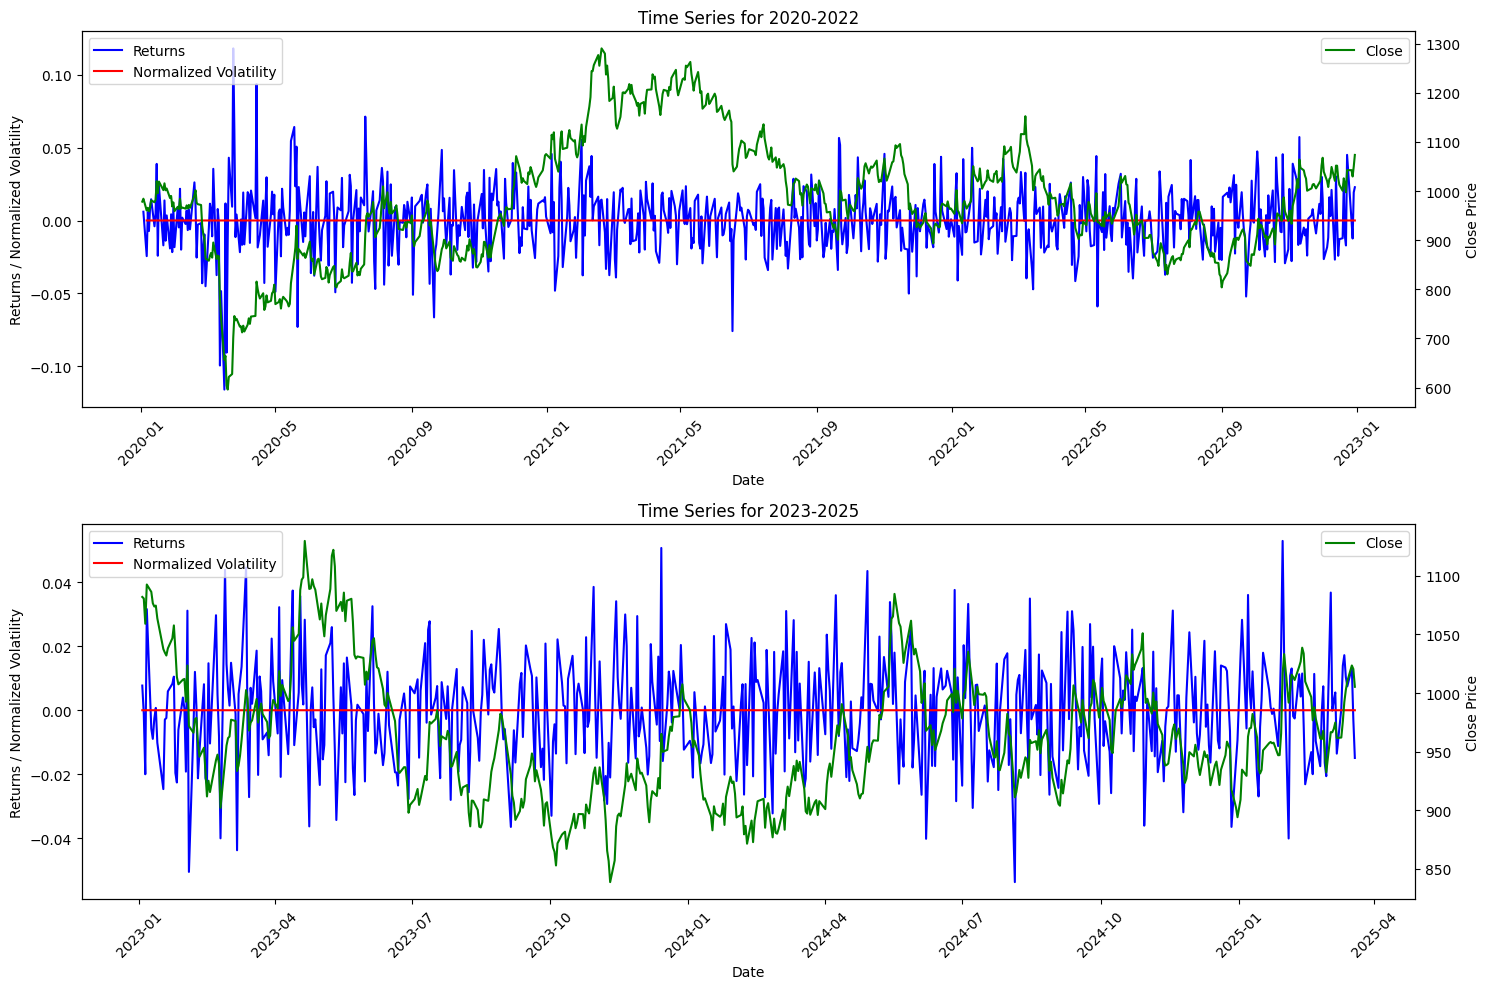

In [35]:

plat_df['Date'] = pd.to_datetime(plat_df['Date'])

plat_df['Normalized_Volatility'] = plat_df['Volatility'] / plat_df['Close']

plt.figure(figsize=(15, 10))


years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

ax1 = plt.subplot(2, 1, 1)  

data_2020_2022 = plat_df[plat_df['Date'].dt.year.isin(years_1)]

sns.lineplot(x='Date', y='Returns', data=data_2020_2022, label='Returns', color='blue', ax=ax1)
sns.lineplot(x='Date', y='Normalized_Volatility', data=data_2020_2022, label='Normalized Volatility', color='red', ax=ax1)


ax2 = ax1.twinx()
sns.lineplot(x='Date', y='Close', data=data_2020_2022, label='Close', color='green', ax=ax2)


ax1.set_xlabel('Date')
ax1.set_ylabel('Returns / Normalized Volatility')
ax1.set_title('Time Series for 2020-2022')


ax2.set_ylabel('Close Price')


ax1.legend(loc='upper left')
ax2.legend(loc='upper right')


ax1.tick_params(axis='x', rotation=45)

ax3 = plt.subplot(2, 1, 2)  
data_2023_2025 = plat_df[plat_df['Date'].dt.year.isin(years_2)]

sns.lineplot(x='Date', y='Returns', data=data_2023_2025, label='Returns', color='blue', ax=ax3)
sns.lineplot(x='Date', y='Normalized_Volatility', data=data_2023_2025, label='Normalized Volatility', color='red', ax=ax3)

ax4 = ax3.twinx()
sns.lineplot(x='Date', y='Close', data=data_2023_2025, label='Close', color='green', ax=ax4)


ax3.set_xlabel('Date')
ax3.set_ylabel('Returns / Normalized Volatility')
ax3.set_title('Time Series for 2023-2025')

ax4.set_ylabel('Close Price')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')

ax3.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/3055890742.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Date'] = pd.to_datetime(plat_df['Date'])


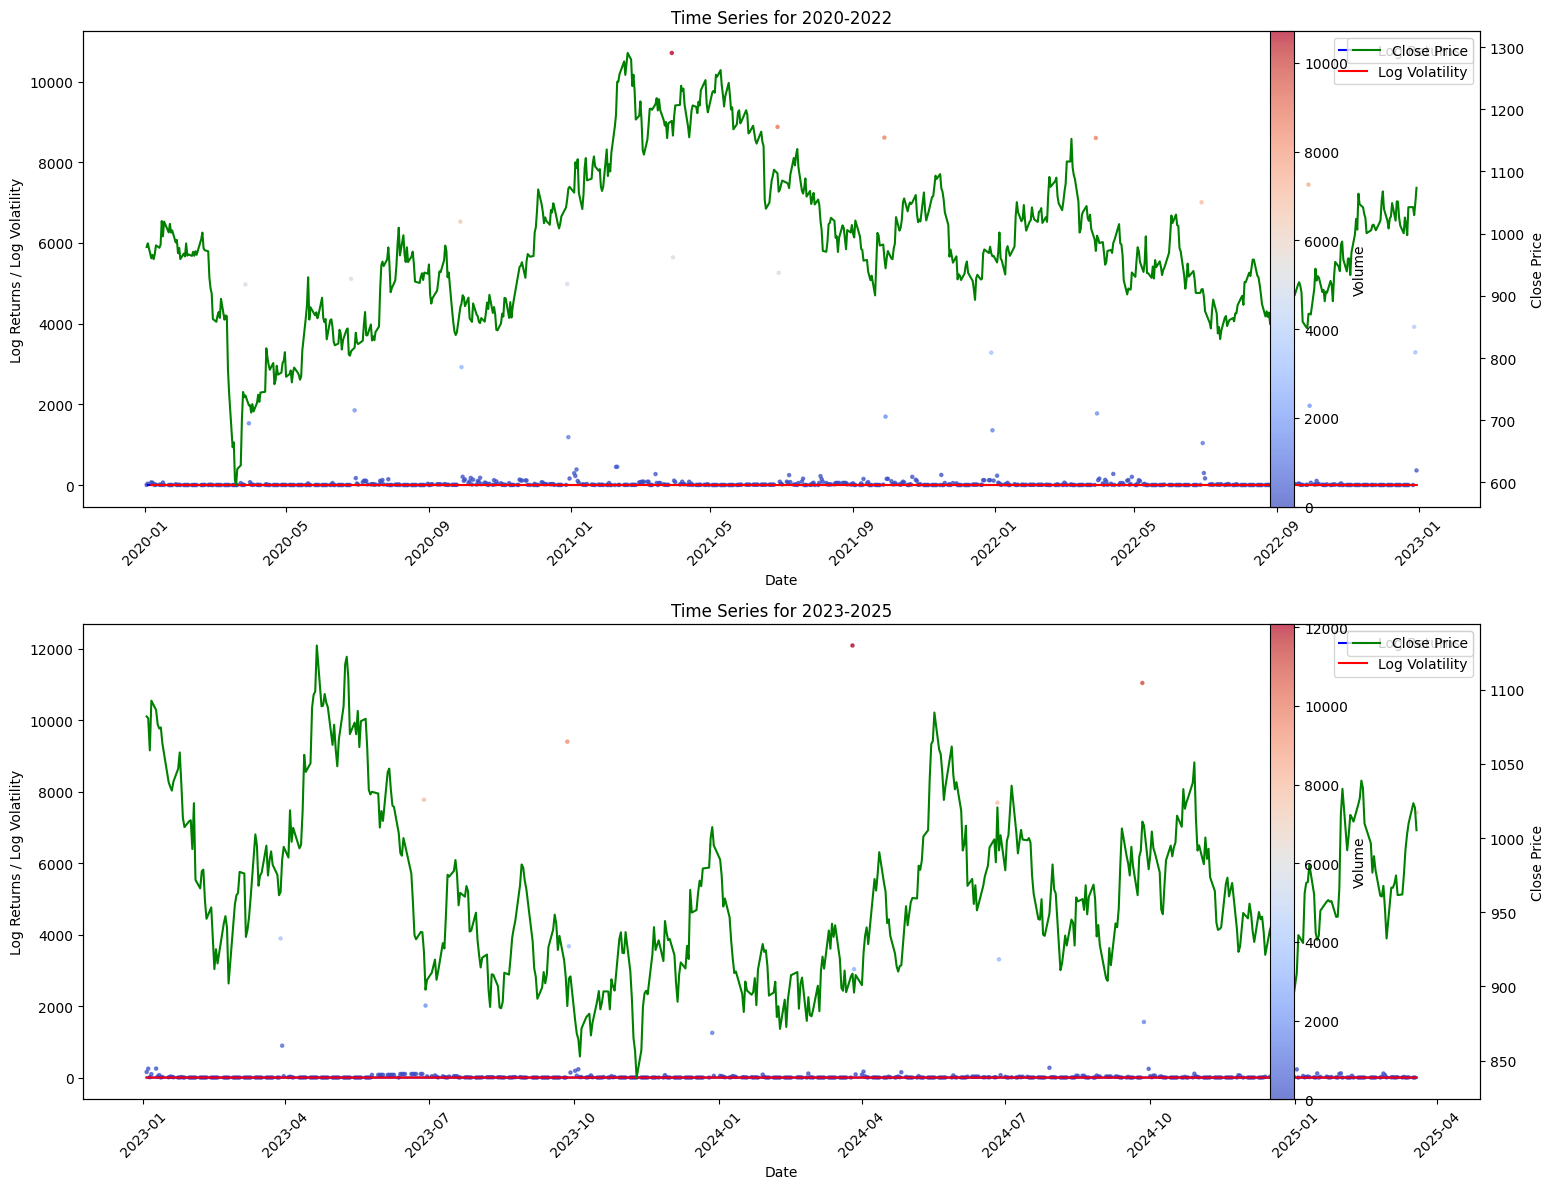

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' is in datetime format
plat_df['Date'] = pd.to_datetime(plat_df['Date'])

# Create a figure with subplots (2 rows, 1 column)
plt.figure(figsize=(15, 12))

# List of years for each plot
years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

# Plot 1 for 2020-2022
ax1 = plt.subplot(2, 1, 1)  # 2 rows, 1 column, first subplot

# Filter data for the years 2020-2022
data_2020_2022 = plat_df[plat_df['Date'].dt.year.isin(years_1)]

# Plot Returns and Volatility for the 2020-2022 period on primary y-axis
sns.lineplot(x='Date', y='Returns', data=data_2020_2022, label='Log Returns', color='blue', ax=ax1)
sns.lineplot(x='Date', y='Volatility', data=data_2020_2022, label='Log Volatility', color='red', ax=ax1)

# Create a secondary y-axis for the Close price
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='Close', data=data_2020_2022, label='Close Price', color='green', ax=ax2)

# Plot Volume as a heatmap using scatter
scatter = ax1.scatter(data_2020_2022['Date'], data_2020_2022['Volume'], c=data_2020_2022['Volume'], cmap='coolwarm', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax1, label='Volume')

# Set titles and labels for the first subplot
ax1.set_xlabel('Date')
ax1.set_ylabel('Log Returns / Log Volatility')
ax1.set_title('Time Series for 2020-2022')

# Set secondary axis labels for Close price
ax2.set_ylabel('Close Price')

# Rotate x-ticks for better readability
ax1.tick_params(axis='x', rotation=45)

# Plot 2 for 2023-2025
ax3 = plt.subplot(2, 1, 2)  # 2 rows, 1 column, second subplot

# Filter data for the years 2023-2025
data_2023_2025 = plat_df[plat_df['Date'].dt.year.isin(years_2)]

# Plot Returns and Volatility for the 2023-2025 period on primary y-axis
sns.lineplot(x='Date', y='Returns', data=data_2023_2025, label='Log Returns', color='blue', ax=ax3)
sns.lineplot(x='Date', y='Volatility', data=data_2023_2025, label='Log Volatility', color='red', ax=ax3)

# Create a secondary y-axis for the Close price
ax4 = ax3.twinx()
sns.lineplot(x='Date', y='Close', data=data_2023_2025, label='Close Price', color='green', ax=ax4)

# Plot Volume as a heatmap using scatter
scatter2 = ax3.scatter(data_2023_2025['Date'], data_2023_2025['Volume'], c=data_2023_2025['Volume'], cmap='coolwarm', s=5, alpha=0.7)
plt.colorbar(scatter2, ax=ax3, label='Volume')

# Set titles and labels for the second subplot
ax3.set_xlabel('Date')
ax3.set_ylabel('Log Returns / Log Volatility')
ax3.set_title('Time Series for 2023-2025')

# Set secondary axis labels for Close price
ax4.set_ylabel('Close Price')

# Rotate x-ticks for better readability
ax3.tick_params(axis='x', rotation=45)

# Adjust layout for the subplots
plt.tight_layout()

# Show the plot
plt.show()



/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/2633600753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Date'] = pd.to_datetime(plat_df['Date'])
/var/folders/sk/yc5mm4gd24l7wfhql0s65d340000gn/T/ipykernel_3149/2633600753.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plat_df['Stationary_Volatility'] = plat_df['Volatility'].diff().fillna(0)


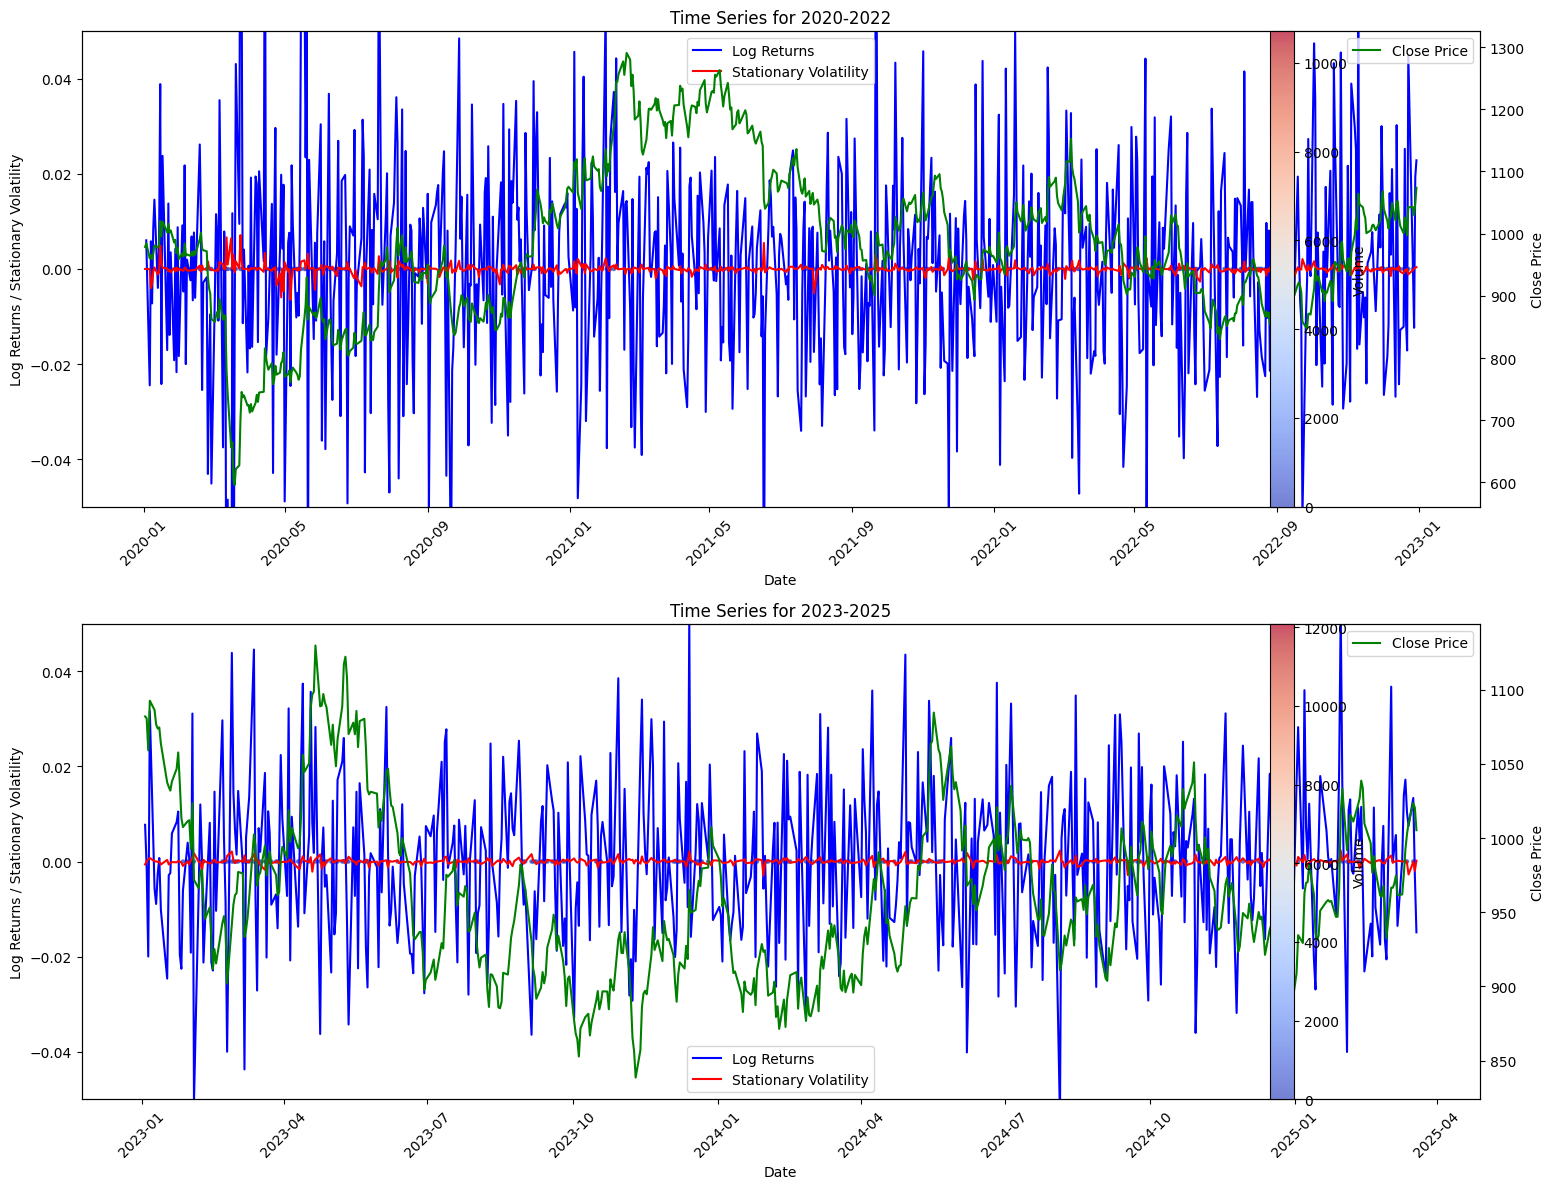

In [41]:


plat_df['Date'] = pd.to_datetime(plat_df['Date'])


plat_df['Stationary_Volatility'] = plat_df['Volatility'].diff().fillna(0)


plt.figure(figsize=(15, 12))


years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

# Plot 1 for 2020-2022
ax1 = plt.subplot(2, 1, 1)  


data_2020_2022 = plat_df[plat_df['Date'].dt.year.isin(years_1)]


sns.lineplot(x='Date', y='Returns', data=data_2020_2022, label='Log Returns', color='blue', ax=ax1)
sns.lineplot(x='Date', y='Stationary_Volatility', data=data_2020_2022, label='Stationary Volatility', color='red', ax=ax1)


ax2 = ax1.twinx()
sns.lineplot(x='Date', y='Close', data=data_2020_2022, label='Close Price', color='green', ax=ax2)

scatter = ax1.scatter(data_2020_2022['Date'], data_2020_2022['Volume'], c=data_2020_2022['Volume'], cmap='coolwarm', s=5, alpha=0.7)
plt.colorbar(scatter, ax=ax1, label='Volume')

ax1.set_xlabel('Date')
ax1.set_ylabel('Log Returns / Stationary Volatility')
ax1.set_title('Time Series for 2020-2022')

ax2.set_ylabel('Close Price')


ax1.set_ylim(-0.05, 0.05)  


ax1.tick_params(axis='x', rotation=45)

# Plot 2 for 2023-2025
ax3 = plt.subplot(2, 1, 2)  # 2 rows, 1 column, second subplot

# Filter data for the years 2023-2025
data_2023_2025 = plat_df[plat_df['Date'].dt.year.isin(years_2)]

# Plot Returns and Stationary Volatility for the 2023-2025 period on primary y-axis
sns.lineplot(x='Date', y='Returns', data=data_2023_2025, label='Log Returns', color='blue', ax=ax3)
sns.lineplot(x='Date', y='Stationary_Volatility', data=data_2023_2025, label='Stationary Volatility', color='red', ax=ax3)

# Create a secondary y-axis for the Close price
ax4 = ax3.twinx()
sns.lineplot(x='Date', y='Close', data=data_2023_2025, label='Close Price', color='green', ax=ax4)

# Plot Volume as a heatmap using scatter
scatter2 = ax3.scatter(data_2023_2025['Date'], data_2023_2025['Volume'], c=data_2023_2025['Volume'], cmap='coolwarm', s=5, alpha=0.7)
plt.colorbar(scatter2, ax=ax3, label='Volume')

# Set titles and labels for the second subplot
ax3.set_xlabel('Date')
ax3.set_ylabel('Log Returns / Stationary Volatility')
ax3.set_title('Time Series for 2023-2025')

# Set secondary axis labels for Close price
ax4.set_ylabel('Close Price')

# Adjust y-axis to zoom in on smaller values for Returns and Volatility
ax3.set_ylim(-0.05, 0.05)  # Adjust as necessary for your specific data range

# Rotate x-ticks for better readability
ax3.tick_params(axis='x', rotation=45)

# Adjust layout for the subplots
plt.tight_layout()

# Show the plot
plt.show()



In [43]:

plat_df = plat_df.drop(columns=['Normalized_Volatility', 'Normalized_Volume', 'Stationary_Volatility'])


plat_df.head()


,Date,Close,Log_Volatility,Volatility,Returns,Volume
0,2020-01-02,978.599976,NaN,NaN,NaN,2
1,2020-01-03,984.500000,NaN,NaN,0.006029,32
2,2020-01-06,960.400024,-3.836325,0.021573,-0.024479,65
3,2020-01-07,966.000000,-4.042295,0.017557,0.005831,55
4,2020-01-08,959.000000,-4.239438,0.014416,-0.007246,23


In [49]:
dxy.head()


,Date,dxy_close
0,2020-01-02,96.849998
1,2020-01-03,96.839996
2,2020-01-06,96.669998
3,2020-01-07,96.980003
4,2020-01-08,97.300003


In [50]:
# Ensure all date columns are of the same datetime type and format

# Convert 'Date' column in plat_df to datetime64[ns]
plat_df['Date'] = pd.to_datetime(plat_df['Date'])

# Convert 'DATE' column in cpi to datetime64[ns] (it was initially in object format)
cpi['Date'] = pd.to_datetime(cpi['DATE'])

# Convert 'Date' column in dxy to datetime64[ns]
dxy['Date'] = pd.to_datetime(dxy['Date'])

# Convert 'observation_date' column in effr to datetime64[ns]
effr['observation_date'] = pd.to_datetime(effr['observation_date'])

# Now you can merge the dataframes
# Merge plat_df with cpi
master_df = plat_df.merge(cpi[['Date', 'cpi_close']], how='left', on='Date')

# Merge with dxy
master_df = master_df.merge(dxy[['Date', 'dxy_close']], how='left', on='Date')

# Merge with effr
master_df = master_df.merge(effr[['observation_date', 'EFFR']], how='left', left_on='Date', right_on='observation_date')

# Drop the redundant observation_date column from effr
master_df = master_df.drop(columns=['observation_date'])

# Print out the first few rows to ensure everything is merged correctly
master_df.head()


        Date       Close  Log_Volatility  Volatility   Returns  Volume  \
0 2020-01-02  978.599976             NaN         NaN       NaN       2   
1 2020-01-03  984.500000             NaN         NaN  0.006029      32   
2 2020-01-06  960.400024       -3.836325    0.021573 -0.024479      65   
3 2020-01-07  966.000000       -4.042295    0.017557  0.005831      55   
4 2020-01-08  959.000000       -4.239438    0.014416 -0.007246      23   

   cpi_close  dxy_close  EFFR  
0        NaN  96.849998  1.55  
1        NaN  96.839996  1.55  
2        NaN  96.669998  1.55  
3        NaN  96.980003  1.55  
4        NaN  97.300003  1.55  


In [51]:
master_df.head()

,Date,Close,Log_Volatility,Volatility,Returns,Volume,cpi_close,dxy_close,EFFR
0,2020-01-02,978.599976,NaN,NaN,NaN,2,NaN,96.849998,1.55
1,2020-01-03,984.500000,NaN,NaN,0.006029,32,NaN,96.839996,1.55
2,2020-01-06,960.400024,-3.836325,0.021573,-0.024479,65,NaN,96.669998,1.55
3,2020-01-07,966.000000,-4.042295,0.017557,0.005831,55,NaN,96.980003,1.55
4,2020-01-08,959.000000,-4.239438,0.014416,-0.007246,23,NaN,97.300003,1.55


In [52]:
master_df = master_df.drop(columns=['cpi_close'])
master_df.head()

,Date,Close,Log_Volatility,Volatility,Returns,Volume,dxy_close,EFFR
0,2020-01-02,978.599976,NaN,NaN,NaN,2,96.849998,1.55
1,2020-01-03,984.500000,NaN,NaN,0.006029,32,96.839996,1.55
2,2020-01-06,960.400024,-3.836325,0.021573,-0.024479,65,96.669998,1.55
3,2020-01-07,966.000000,-4.042295,0.017557,0.005831,55,96.980003,1.55
4,2020-01-08,959.000000,-4.239438,0.014416,-0.007246,23,97.300003,1.55


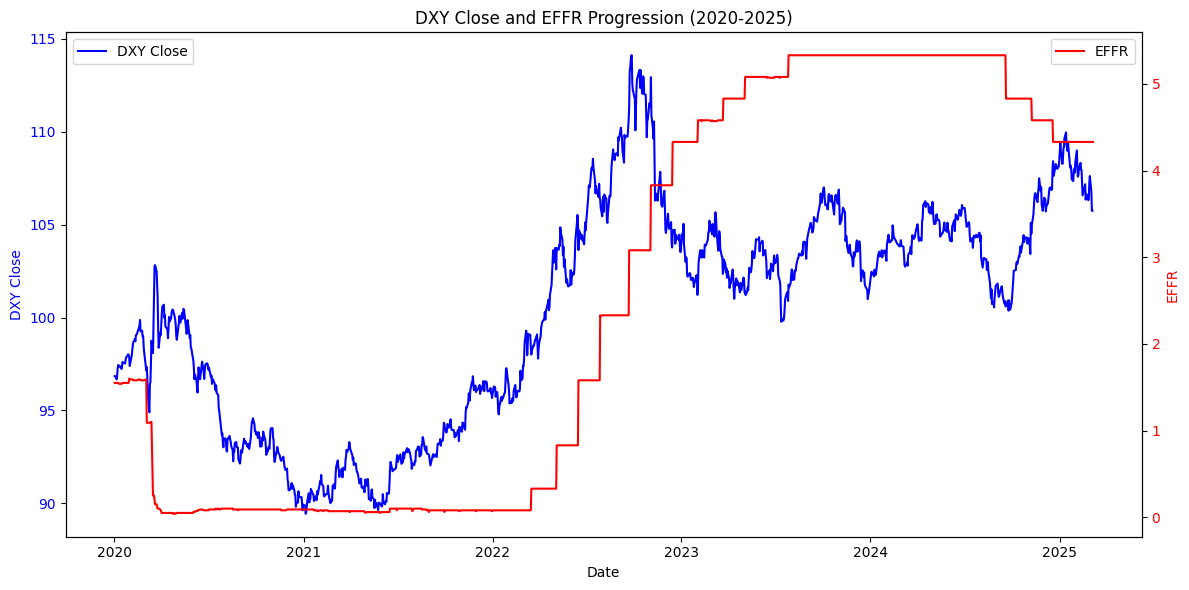

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the years of interest
years = [2020, 2021, 2022, 2023, 2024, 2025]
master_df['Year'] = master_df['Date'].dt.year
filtered_df = master_df[master_df['Year'].isin(years)]

# Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot dxy_close on the first axis
sns.lineplot(x='Date', y='dxy_close', data=filtered_df, label='DXY Close', color='blue', ax=ax1)
ax1.set_xlabel('Date')
ax1.set_ylabel('DXY Close', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis to plot EFFR
ax2 = ax1.twinx()
sns.lineplot(x='Date', y='EFFR', data=filtered_df, label='EFFR', color='red', ax=ax2)
ax2.set_ylabel('EFFR', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add titles and legends
plt.title('DXY Close and EFFR Progression (2020-2025)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()
